<a href="https://colab.research.google.com/github/ecastrofelix/Proyecto/blob/main/EDA_Emigracio%CC%81n_completa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/")
FILE_NAME = "03_mig_interest_quinquenal_proyecciones.csv"
path = DATA_DIR / FILE_NAME

In [ ]:
migracion = pd.read_csv(path, low_memory=False)

In [ ]:
print("Filas:", migracion.shape[0])
print("Columnas:", migracion.shape[1])

Filas: 23040
Columnas: 10


In [ ]:
migracion.head()

,RENGLON,ANIO,ENTIDAD,CVE_GEO,EDAD,SEXO,EMIGRANTES,INMIGRANTES,ENTIDAD_FEDERATIVA,FECHA
0,1,1970-1974,Aguascalientes,1,00--04,Hombres,2597,3470,Aguascalientes,1974-01-01
1,2,1970-1974,Aguascalientes,1,00--04,Mujeres,2567,3308,Aguascalientes,1974-01-01
2,3,1970-1974,Aguascalientes,1,05--09,Hombres,1137,2042,Aguascalientes,1974-01-01
3,4,1970-1974,Aguascalientes,1,05--09,Mujeres,1136,1962,Aguascalientes,1974-01-01
4,5,1970-1974,Aguascalientes,1,10--14,Hombres,1041,1836,Aguascalientes,1974-01-01


In [ ]:
migracion.tail()

,RENGLON,ANIO,ENTIDAD,CVE_GEO,EDAD,SEXO,EMIGRANTES,INMIGRANTES,ENTIDAD_FEDERATIVA,FECHA
23035,23036,2065-2069,Zacatecas,32,75--79,Mujeres,562,400,Zacatecas,2069-01-01
23036,23037,2065-2069,Zacatecas,32,80--84,Hombres,338,284,Zacatecas,2069-01-01
23037,23038,2065-2069,Zacatecas,32,80--84,Mujeres,578,317,Zacatecas,2069-01-01
23038,23039,2065-2069,Zacatecas,32,85--89,Hombres,279,215,Zacatecas,2069-01-01
23039,23040,2065-2069,Zacatecas,32,85--89,Mujeres,479,331,Zacatecas,2069-01-01


In [ ]:
estados = migracion['ENTIDAD_FEDERATIVA'].unique()
estados

array(['Aguascalientes', 'Baja California', 'Baja California Sur',
       'Campeche', 'Coahuila', 'Colima', 'Chiapas', 'Chihuahua',
       'Ciudad de México', 'Durango', 'Guanajuato', 'Guerrero', 'Hidalgo',
       'Jalisco', 'Estado de México', 'Michoacán', 'Morelos', 'Nayarit',
       'Nuevo León', 'Oaxaca', 'Puebla', 'Querétaro', 'Quintana Roo',
       'San Luis Potosí', 'Sinaloa', 'Sonora', 'Tabasco', 'Tamaulipas',
       'Tlaxcala', 'Veracruz', 'Yucatán', 'Zacatecas'], dtype=object)

In [ ]:
migracion.dtypes

,0
RENGLON,int64
ANIO,object
ENTIDAD,object
CVE_GEO,int64
EDAD,object
SEXO,object
EMIGRANTES,int64
INMIGRANTES,int64
ENTIDAD_FEDERATIVA,object
FECHA,object


In [ ]:
migracion.isnull().sum()

,0
RENGLON,0
ANIO,0
ENTIDAD,0
CVE_GEO,0
EDAD,0
SEXO,0
EMIGRANTES,0
INMIGRANTES,0
ENTIDAD_FEDERATIVA,0
FECHA,0


In [ ]:
migracion['ANIO_INICIO'] = migracion['ANIO'].apply(lambda x: int(x.split('-')[0]))
migracion['ANIO_INICIO'] = pd.to_datetime(migracion['ANIO_INICIO'], format='%Y')

migracion_agrupado = migracion.groupby(['ENTIDAD_FEDERATIVA', 'ANIO_INICIO'])['EMIGRANTES'].sum().reset_index()

display(migracion_agrupado.head())

,ENTIDAD_FEDERATIVA,ANIO_INICIO,EMIGRANTES
0,Aguascalientes,1970-01-01,21882
1,Aguascalientes,1975-01-01,15742
2,Aguascalientes,1980-01-01,18464
3,Aguascalientes,1985-01-01,21283
4,Aguascalientes,1990-01-01,23384


**Top 5 de los estados con mayor número de emigrantes.**

In [ ]:
# Calcular el total de emigrantes por entidad
total_emigrantes_por_entidad = migracion_agrupado.groupby('ENTIDAD_FEDERATIVA')['EMIGRANTES'].sum().sort_values(ascending=False)

# Mostrar los 3 estados con más emigrantes
display(total_emigrantes_por_entidad.head(5))

,EMIGRANTES
ENTIDAD_FEDERATIVA,
Ciudad de México,14045529
Estado de México,9496725
Veracruz,6169435
Jalisco,3765638
Puebla,3593884


**Gráfica para los 32 estados destacando los 5 con mayor número de migrantes.**

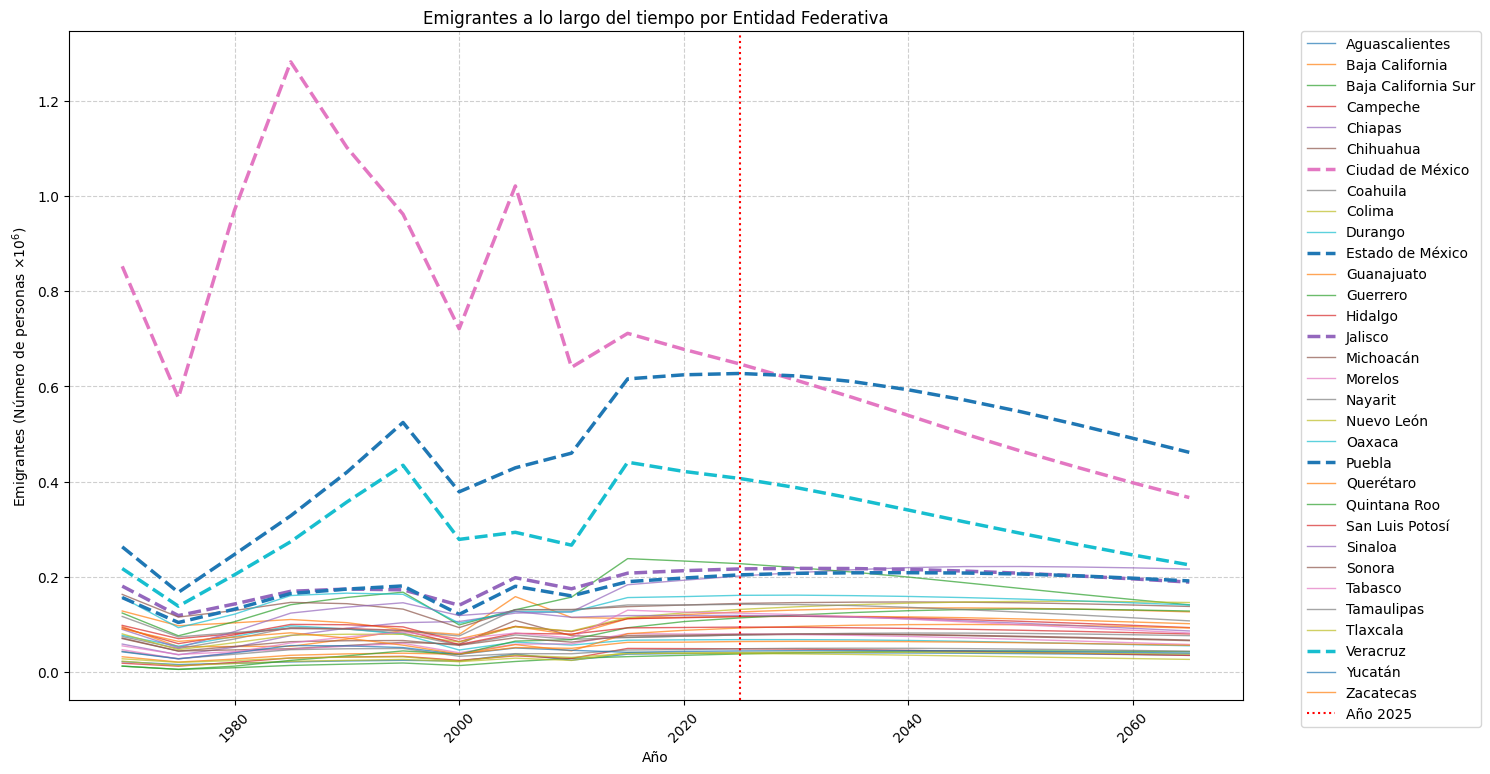

In [ ]:
fig = plt.figure(figsize=(15, 8))

# Obtener los 3 estados con más emigrantes
estados_a_resaltar = total_emigrantes_por_entidad.head(5).index.tolist()

for entidad in migracion_agrupado['ENTIDAD_FEDERATIVA'].unique():
    df_entidad = migracion_agrupado[migracion_agrupado['ENTIDAD_FEDERATIVA'] == entidad]
    if entidad in estados_a_resaltar:
        sns.lineplot(x='ANIO_INICIO', y='EMIGRANTES', data=df_entidad, label=entidad, linestyle='--', linewidth=2.5)
    else:
        sns.lineplot(x='ANIO_INICIO', y='EMIGRANTES', data=df_entidad, label=entidad, linewidth=1.0, alpha=0.7)

plt.axvline(pd.to_datetime('2025-01-01'), color='red', linestyle=':', label='Año 2025')

plt.title('Emigrantes a lo largo del tiempo por Entidad Federativa')
plt.xlabel('Año')
plt.ylabel(r'Emigrantes (Número de personas $\times 10^{6}$)') # Ajustar la escala a millones
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

# Formatear el eje y para mostrar valores en millones
plt.ticklabel_format(style='plain', axis='y') # Evita la notación científica automática
def millions_formatter(x, pos):
    return f'{x*1e-6:.1f}'

# Obtener el objeto de eje y establecer el formateador
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(millions_formatter))

plt.tight_layout()
plt.show()

In [ ]:
fig.savefig('emigrantes_por_entidad.pdf', dpi=300, bbox_inches='tight')


# Aplicar clustering usando k-means

Preparar, escalar y aplicar el algoritmo K-Means a los datos de emigración por entidad federativa hasta el año 2025 para identificar el número óptimo de clusters, visualizarlos y analizar la agrupación de los 5 estados con mayor número de emigrantes.

## Preparar Datos para Clustering (hasta 2025)

Filtrar el DataFrame 'migracion_agrupado' para incluir solo los
datos hasta el año 2025 y luego pivotar la tabla para tener las entidades federativas como filas y los años como columnas, con los valores de emigrantes correspondientes.


In [ ]:
migracion_filtrado_2025 = migracion_agrupado[migracion_agrupado['ANIO_INICIO'].dt.year <= 2025]
df_clustering_2025 = migracion_filtrado_2025.pivot_table(index='ENTIDAD_FEDERATIVA', columns='ANIO_INICIO', values='EMIGRANTES')
df_clustering_2025 = df_clustering_2025.fillna(0)
display(df_clustering_2025.head())

ANIO_INICIO,1970-01-01,1975-01-01,1980-01-01,1985-01-01,1990-01-01,1995-01-01,2000-01-01,2005-01-01,2010-01-01,2015-01-01,2020-01-01,2025-01-01
ENTIDAD_FEDERATIVA,,,,,,,,,,,,
Aguascalientes,21882.0,15742.0,18464.0,21283.0,23384.0,24627.0,23133.0,37758.0,24874.0,37571.0,38907.0,39738.0
Baja California,95495.0,53229.0,53678.0,54022.0,69099.0,87199.0,79039.0,158365.0,114625.0,112513.0,120507.0,126355.0
Baja California Sur,12527.0,5525.0,9086.0,13948.0,16600.0,19019.0,13615.0,22209.0,28724.0,32368.0,35149.0,38025.0
Campeche,18560.0,12359.0,20406.0,29673.0,31709.0,33033.0,24614.0,34009.0,28675.0,49614.0,49237.0,48884.0
Chiapas,58789.0,36293.0,52088.0,76558.0,92148.0,103661.0,106137.0,123764.0,126496.0,183352.0,192830.0,201770.0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled_2025 = scaler.fit_transform(df_clustering_2025)

# Convert the scaled array back to a DataFrame for better readability and to retain column/index names
df_scaled_2025 = pd.DataFrame(df_scaled_2025, columns=df_clustering_2025.columns, index=df_clustering_2025.index)
display(df_scaled_2025.head())

ANIO_INICIO,1970-01-01,1975-01-01,1980-01-01,1985-01-01,1990-01-01,1995-01-01,2000-01-01,2005-01-01,2010-01-01,2015-01-01,2020-01-01,2025-01-01
ENTIDAD_FEDERATIVA,,,,,,,,,,,,
Aguascalientes,-0.620296,-0.585533,-0.506139,-0.499395,-0.564859,-0.605389,-0.573572,-0.541597,-0.725152,-0.706779,-0.725358,-0.745643
Baja California,-0.115230,-0.204803,-0.292433,-0.349260,-0.329501,-0.262286,-0.153904,0.133991,-0.010612,-0.223095,-0.182922,-0.153052
Baja California Sur,-0.684482,-0.689300,-0.563052,-0.533032,-0.599785,-0.636139,-0.645021,-0.628695,-0.694501,-0.740360,-0.750339,-0.757363
Campeche,-0.643089,-0.619891,-0.494354,-0.460920,-0.521998,-0.559296,-0.562455,-0.562597,-0.694891,-0.629052,-0.656689,-0.683071
Chiapas,-0.367074,-0.376810,-0.302082,-0.245914,-0.210836,-0.172020,0.049512,-0.059829,0.083898,0.234107,0.297844,0.362901


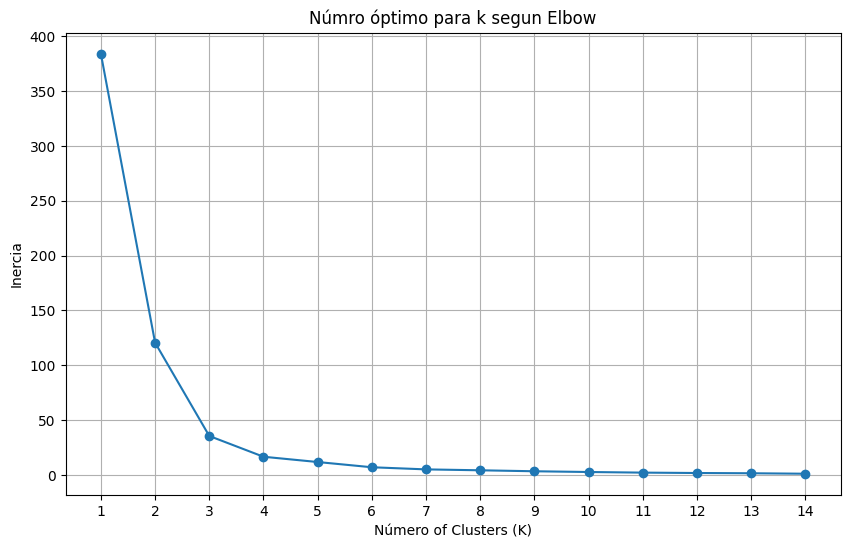

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_2025 = []
for k in range(1, 15):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is added to suppress warning
    kmeans.fit(df_scaled_2025)
    inertia_2025.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 15), inertia_2025, marker='o')
plt.title('Númro óptimo para k segun Elbow')
plt.xlabel('Número of Clusters (K)')
plt.ylabel('Inercia')
plt.xticks(range(1, 15))
plt.grid(True)
plt.show()

**Interpretación:**

Basándonos en el gráfico anterior, el número óptimo de clusters parece ser 4, ya que es aquí donde la tasa de disminución de la inercia se ralentiza significativamente.

In [ ]:
optimal_k_2025 = 4
kmeans_2025 = KMeans(n_clusters=optimal_k_2025, random_state=42, n_init=10)
df_clustering_2025['Cluster'] = kmeans_2025.fit_predict(df_scaled_2025)
display(df_clustering_2025.head())

ANIO_INICIO,1970-01-01 00:00:00,1975-01-01 00:00:00,1980-01-01 00:00:00,1985-01-01 00:00:00,1990-01-01 00:00:00,1995-01-01 00:00:00,2000-01-01 00:00:00,2005-01-01 00:00:00,2010-01-01 00:00:00,2015-01-01 00:00:00,2020-01-01 00:00:00,2025-01-01 00:00:00,Cluster
ENTIDAD_FEDERATIVA,,,,,,,,,,,,,
Aguascalientes,21882.0,15742.0,18464.0,21283.0,23384.0,24627.0,23133.0,37758.0,24874.0,37571.0,38907.0,39738.0,0
Baja California,95495.0,53229.0,53678.0,54022.0,69099.0,87199.0,79039.0,158365.0,114625.0,112513.0,120507.0,126355.0,3
Baja California Sur,12527.0,5525.0,9086.0,13948.0,16600.0,19019.0,13615.0,22209.0,28724.0,32368.0,35149.0,38025.0,0
Campeche,18560.0,12359.0,20406.0,29673.0,31709.0,33033.0,24614.0,34009.0,28675.0,49614.0,49237.0,48884.0,0
Chiapas,58789.0,36293.0,52088.0,76558.0,92148.0,103661.0,106137.0,123764.0,126496.0,183352.0,192830.0,201770.0,3




Para visualizar los clusters e identificar la agrupación de los 5 estados con mayor número de emigrantes, vamos a reducir la dimensionalidad de los datos escalados. Aplicamos Análisis de Componentes Principales (PCA) ya que me permite proyectar los datos en un espacio 2D usando parte de la varianza.



In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca_2025 = pca.fit_transform(df_scaled_2025)
df_pca_2025 = pd.DataFrame(data = df_pca_2025, columns = ['PC1', 'PC2'], index=df_clustering_2025.index)
df_pca_2025['Cluster'] = df_clustering_2025['Cluster']

top_5_states = total_emigrantes_por_entidad.head(5).index.tolist()

display(df_pca_2025.head())

,PC1,PC2,Cluster
ENTIDAD_FEDERATIVA,,,
Aguascalientes,-2.132533,-0.277650,0
Baja California,-0.616744,0.087331,3
Baja California Sur,-2.283791,-0.208693,0
Campeche,-2.043735,-0.184849,0
Chiapas,-0.212164,0.825735,3


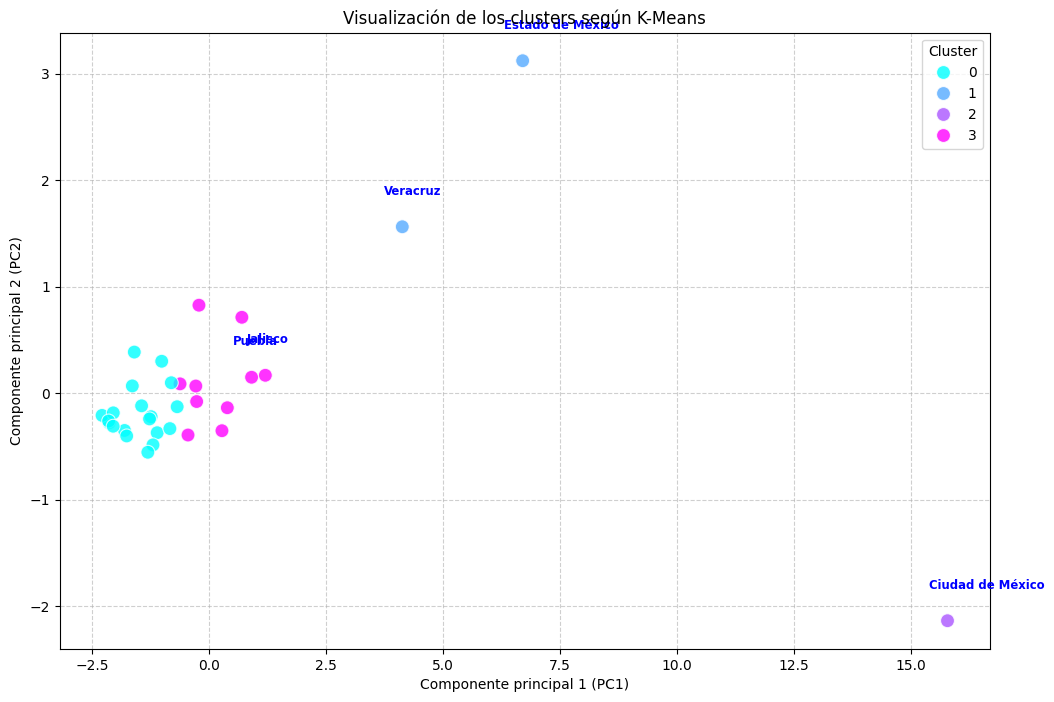

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster', data=df_pca_2025,
    palette='cool', s=100, alpha=0.8, legend='full'
)

for i, row in df_pca_2025.iterrows():
    if i in top_5_states:
        plt.text(row['PC1'] - 0.4, row['PC2'] + 0.3, i ,
                 horizontalalignment='left',
                 size='small',
                 color='blue',
                 weight='semibold')

plt.title('Visualización de los clusters según K-Means')
plt.xlabel('Componente principal 1 (PC1)')
plt.ylabel('Componente principal 2 (PC2)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Visualizar Clusters

Generar una visualización de las tendencias promedio de emigración para cada cluster, utilizando los datos hasta 2025, para entender las agrupaciones.

Para visualizar las tendencias promedio de emigración por cluster, primero hay que agrupar por cluster y año para calcular la emigración promedio para cada cluster a lo largo del tiempo.


In [ ]:
migracion_con_clusters_2025 = migracion_filtrado_2025.merge(
    df_clustering_2025[['Cluster']],
    left_on='ENTIDAD_FEDERATIVA',
    right_index=True
)

cluster_trends_2025 = migracion_con_clusters_2025.groupby(['Cluster', 'ANIO_INICIO'])['EMIGRANTES'].mean().reset_index()
display(cluster_trends_2025.head())

,Cluster,ANIO_INICIO,EMIGRANTES
0,0,1970-01-01,52196.842105
1,0,1975-01-01,34089.368421
2,0,1980-01-01,43666.947368
3,0,1985-01-01,54922.789474
4,0,1990-01-01,56601.052632


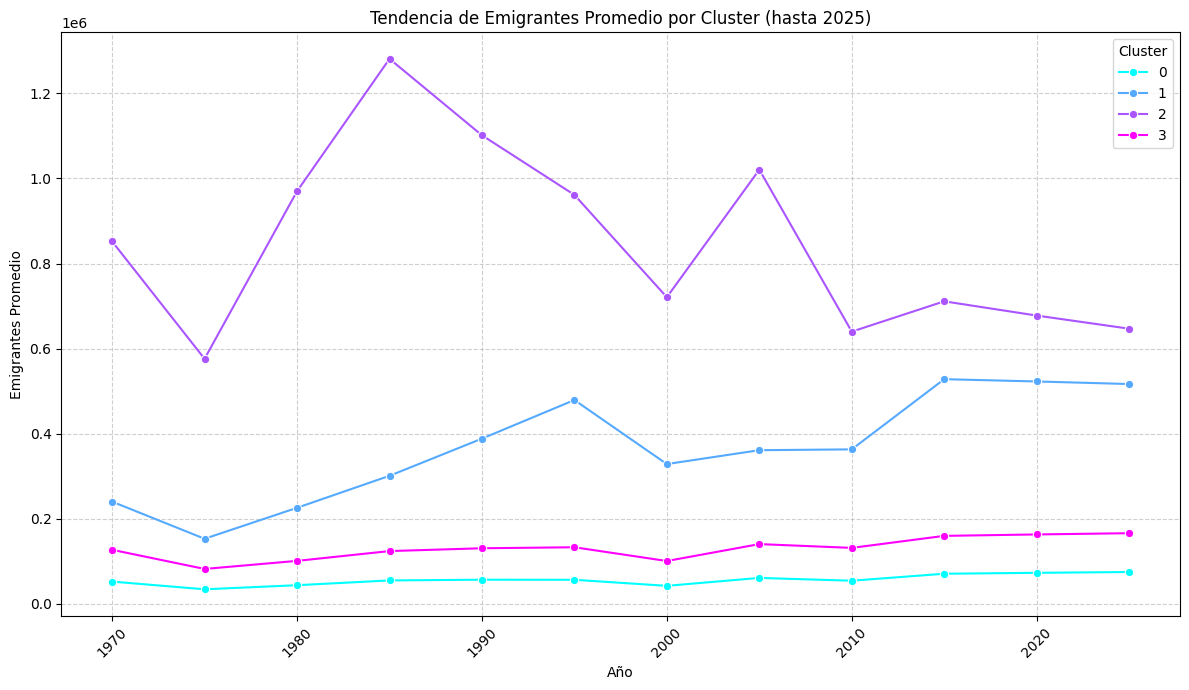

In [ ]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=cluster_trends_2025, x='ANIO_INICIO', y='EMIGRANTES', hue='Cluster', palette='cool', marker='o')
plt.title('Tendencia de Emigrantes Promedio por Cluster (hasta 2025)')
plt.xlabel('Año')
plt.ylabel('Emigrantes Promedio')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Revisamos a qué cluster pertenecen los 5 estados con mayor número de emigrantes en esta nueva agrupación basada en datos hasta 2025.


In [ ]:
top_5_states_clusters = df_clustering_2025[df_clustering_2025.index.isin(top_5_states)][['Cluster']]
display(top_5_states_clusters)

ANIO_INICIO,Cluster
ENTIDAD_FEDERATIVA,
Ciudad de México,2
Estado de México,1
Jalisco,3
Puebla,3
Veracruz,1


**¿Conclusiones parciales?:**

*   El método de Elbow para los datos de emigración hasta 2025 sugirió un número óptimo de **4 clusters**.
*   Los 5 estados con mayor número de emigrantes se distribuyen en tres de los cuatro clusters identificados:
    *   **Cluster 1** incluye al Estado de México y Veracruz.
    *   **Cluster 2** incluye a la Ciudad de México.
    *   **Cluster 3** incluye a Jalisco y Puebla.
*   La visualización PCA bidimensional muestra una separación clara entre los 4 clusters, con los estados principales resaltados dentro de sus respectivas agrupaciones.
*   El análisis de tendencias promedio por cluster revela patrones de emigración distintos a lo largo del tiempo para cada grupo.

**¿Qué serguría?**
*    Analizar las características socioeconómicas o geográficas comunes de los estados dentro de cada cluster para comprender mejor los factores que impulsan sus patrones de emigración específicos.
*   **Evaluar la estabilidad de los clusters:** Reaplicar el análisis de clustering con datos más recientes o usando diferentes periodos para evaluar si la composición y las tendencias de los clusters permanecen estables, lo que podría indicar la robustez de estas agrupaciones.


---

---

# Relación con violencia y pobreza

---

---

In [ ]:
DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/")
FILE_NAME = "Estatal_Victimas_2015_2025_ene2026.csv"
path = DATA_DIR / FILE_NAME

In [ ]:
violencia = pd.read_csv(path, low_memory=False, encoding='latin1')

In [ ]:
violencia.head()

,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Sexo,Rango de edad,Enero,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,0
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,Mujer,Menores de edad (0-17),0,...,0,0,1,0,0,1,0,0,0,0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,0
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,Mujer,Menores de edad (0-17),0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
violencia.tail()


,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Sexo,Rango de edad,Enero,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
80955,2025,32,Zacatecas,Libertad personal,Otros delitos que atentan contra la libertad p...,Otros delitos que atentan contra la libertad p...,Otros delitos que atentan contra la libertad p...,No identificado,No identificado,0,...,0,0,0,0,2,2,0,0,0,0
80956,2025,32,Zacatecas,El patrimonio,Extorsión,Extorsión,Extorsión,No identificado,No identificado,0,...,2,1,0,0,0,0,1,0,0,2
80957,2025,32,Zacatecas,La sociedad,Corrupción de menores,Corrupción de menores,Corrupción de menores,No identificado,No identificado,1,...,1,0,1,0,1,0,0,0,0,1
80958,2025,32,Zacatecas,La sociedad,Trata de personas,Trata de personas,Trata de personas,No identificado,No identificado,0,...,0,0,2,0,0,0,0,0,0,0
80959,2025,32,Zacatecas,La sociedad,Otros delitos contra la sociedad,Otros delitos contra la sociedad,Otros delitos contra la sociedad,No identificado,No identificado,0,...,0,0,0,0,0,0,0,0,0,0


## Víctima por entidad entre 2015-2019

In [ ]:
meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
violencia_2015_2019 = violencia[(violencia['Año'] >= 2015) & (violencia['Año'] <= 2019)].copy()
violencia_2015_2019['Total_Victimas'] = violencia_2015_2019[meses].sum(axis=1)
total_victimas_por_entidad_2015_2019 = violencia_2015_2019.groupby('Entidad')['Total_Victimas'].sum().reset_index()
total_victimas_por_entidad_2015_2019 = total_victimas_por_entidad_2015_2019.rename(columns={'Entidad': 'ENTIDAD_FEDERATIVA'})
display(total_victimas_por_entidad_2015_2019.head())

,ENTIDAD_FEDERATIVA,Total_Victimas
0,Aguascalientes,23672
1,Baja California,88940
2,Baja California Sur,13705
3,Campeche,2454
4,Chiapas,20540


## Víctimas por entidad entre 2020-2024

In [ ]:
violencia_2020_2024 = violencia[(violencia['Año'] >= 2020) & (violencia['Año'] <= 2024)].copy()
violencia_2020_2024['Total_Victimas'] = violencia_2020_2024[meses].sum(axis=1)
total_victimas_por_entidad_2020_2024 = violencia_2020_2024.groupby('Entidad')['Total_Victimas'].sum().reset_index()
total_victimas_por_entidad_2020_2024 = total_victimas_por_entidad_2020_2024.rename(columns={'Entidad': 'ENTIDAD_FEDERATIVA'})
display(total_victimas_por_entidad_2020_2024.head())

,ENTIDAD_FEDERATIVA,Total_Victimas
0,Aguascalientes,27687
1,Baja California,97932
2,Baja California Sur,14766
3,Campeche,17118
4,Chiapas,19040


## Migración para los quinquenios de interes (2015-2025)

In [ ]:
migracion_2016_2025 = migracion_agrupado[(migracion_agrupado['ANIO_INICIO'].dt.year >= 2006) & (migracion_agrupado['ANIO_INICIO'].dt.year <= 2025)]
display(migracion_2016_2025.head())

,ENTIDAD_FEDERATIVA,ANIO_INICIO,EMIGRANTES
8,Aguascalientes,2010-01-01,24874
9,Aguascalientes,2015-01-01,37571
10,Aguascalientes,2020-01-01,38907
11,Aguascalientes,2025-01-01,39738
28,Baja California,2010-01-01,114625


**Tabla pivote para que cada quinquenio esté en una columna**

In [ ]:
df_migracion_pivot = migracion_2016_2025.pivot_table(index='ENTIDAD_FEDERATIVA', columns='ANIO_INICIO', values='EMIGRANTES')
df_migracion_pivot = df_migracion_pivot.fillna(0)
display(df_migracion_pivot.head())

ANIO_INICIO,2010-01-01,2015-01-01,2020-01-01,2025-01-01
ENTIDAD_FEDERATIVA,,,,
Aguascalientes,24874.0,37571.0,38907.0,39738.0
Baja California,114625.0,112513.0,120507.0,126355.0
Baja California Sur,28724.0,32368.0,35149.0,38025.0
Campeche,28675.0,49614.0,49237.0,48884.0
Chiapas,126496.0,183352.0,192830.0,201770.0


**Fusionar todo en el data frame `df_final`**

In [ ]:
total_victimas_por_entidad_2015_2019 = total_victimas_por_entidad_2015_2019.rename(columns={'Total_Victimas': 'Total_Victimas_2015_2019'})
total_victimas_por_entidad_2020_2024 = total_victimas_por_entidad_2020_2024.rename(columns={'Total_Victimas': 'Total_Victimas_2020_2024'})
display(total_victimas_por_entidad_2015_2019.head())
display(total_victimas_por_entidad_2020_2024.head())

,ENTIDAD_FEDERATIVA,Total_Victimas_2015_2019
0,Aguascalientes,23672
1,Baja California,88940
2,Baja California Sur,13705
3,Campeche,2454
4,Chiapas,20540


,ENTIDAD_FEDERATIVA,Total_Victimas_2020_2024
0,Aguascalientes,27687
1,Baja California,97932
2,Baja California Sur,14766
3,Campeche,17118
4,Chiapas,19040


In [ ]:
total_victimas_por_entidad_2015_2019

,ENTIDAD_FEDERATIVA,Total_Victimas_2015_2019
0,Aguascalientes,23672
1,Baja California,88940
2,Baja California Sur,13705
3,Campeche,2454
4,Chiapas,20540
5,Chihuahua,51784
6,Ciudad de México,85594
7,Coahuila de Zaragoza,33573
8,Colima,10906
9,Durango,27700


In [ ]:
emigracion_2010 = df_migracion_pivot.loc[:, pd.to_datetime('2010-01-01')].reset_index()
emigracion_2010.rename(columns={pd.to_datetime('2010-01-01'): 'EMIGRANTES_2010'}, inplace=True)
emigracion_2015 = df_migracion_pivot.loc[:, pd.to_datetime('2015-01-01')].reset_index()
emigracion_2015.rename(columns={pd.to_datetime('2015-01-01'): 'EMIGRANTES_2015'}, inplace=True)

emigracion_2020 = df_migracion_pivot.loc[:, pd.to_datetime('2020-01-01')].reset_index()
emigracion_2020.rename(columns={pd.to_datetime('2020-01-01'): 'EMIGRANTES_2020'}, inplace=True)
emigracion_2025 = df_migracion_pivot.loc[:, pd.to_datetime('2025-01-01')].reset_index()
emigracion_2025.rename(columns={pd.to_datetime('2025-01-01'): 'EMIGRANTES_2025'}, inplace=True)

In [ ]:
df_final = emigracion_2020.merge(emigracion_2025, on='ENTIDAD_FEDERATIVA', how='left')
df_final = df_final.merge(emigracion_2015, on='ENTIDAD_FEDERATIVA', how='left')
df_final = df_final.merge(emigracion_2010, on='ENTIDAD_FEDERATIVA', how='left')
display(df_final.head())

,ENTIDAD_FEDERATIVA,EMIGRANTES_2020,EMIGRANTES_2025,EMIGRANTES_2015,EMIGRANTES_2010
0,Aguascalientes,38907.0,39738.0,37571.0,24874.0
1,Baja California,120507.0,126355.0,112513.0,114625.0
2,Baja California Sur,35149.0,38025.0,32368.0,28724.0
3,Campeche,49237.0,48884.0,49614.0,28675.0
4,Chiapas,192830.0,201770.0,183352.0,126496.0


In [ ]:
df_final['Total_Victimas_2015_2019'] = total_victimas_por_entidad_2015_2019['Total_Victimas_2015_2019']
df_final['Total_Victimas_2020_2024'] = total_victimas_por_entidad_2020_2024['Total_Victimas_2020_2024']
df_final

,ENTIDAD_FEDERATIVA,EMIGRANTES_2020,EMIGRANTES_2025,EMIGRANTES_2015,EMIGRANTES_2010,Total_Victimas_2015_2019,Total_Victimas_2020_2024
0,Aguascalientes,38907.0,39738.0,37571.0,24874.0,23672,27687
1,Baja California,120507.0,126355.0,112513.0,114625.0,88940,97932
2,Baja California Sur,35149.0,38025.0,32368.0,28724.0,13705,14766
3,Campeche,49237.0,48884.0,49614.0,28675.0,2454,17118
4,Chiapas,192830.0,201770.0,183352.0,126496.0,20540,19040
5,Chihuahua,75407.0,77870.0,73086.0,76290.0,51784,64708
6,Ciudad de México,677682.0,646796.0,711155.0,639896.0,85594,92708
7,Coahuila,75327.0,77977.0,72463.0,68685.0,33573,31574
8,Colima,39640.0,38988.0,40979.0,24394.0,10906,17167
9,Durango,67640.0,68135.0,66904.0,56620.0,27700,21388


**Mostrar la matríz de correlación**

In [ ]:
df_final.corr(numeric_only=True)

,EMIGRANTES_2020,EMIGRANTES_2025,EMIGRANTES_2015,EMIGRANTES_2010,Total_Victimas_2015_2019,Total_Victimas_2020_2024
EMIGRANTES_2020,1.000000,0.999294,0.998965,0.978339,0.178106,0.201292
EMIGRANTES_2025,0.999294,1.000000,0.996579,0.974635,0.178353,0.202254
EMIGRANTES_2015,0.998965,0.996579,1.000000,0.980618,0.177996,0.200143
EMIGRANTES_2010,0.978339,0.974635,0.980618,1.000000,0.177750,0.191791
Total_Victimas_2015_2019,0.178106,0.178353,0.177996,0.177750,1.000000,0.992648
Total_Victimas_2020_2024,0.201292,0.202254,0.200143,0.191791,0.992648,1.000000


In [ ]:
DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/")
FILE_NAME = "Pobreza_Multidimensional_Entidad.xlsx"
path = DATA_DIR / FILE_NAME

In [ ]:
pobreza = pd.read_excel(path )

In [ ]:
pobreza.head(33)

,Entidad Federativa,2016,2018,2020,2022,2024 (Est.),2025 (Proj.)
0,Nacional,43.2,41.9,43.9,36.3,29.6,28.9
1,Aguascalientes,28.2,26.2,27.6,26.3,23.1,22.5
2,Baja California,22.2,23.3,22.5,13.4,9.9,9.5
3,Baja California Sur,22.1,18.1,27.6,13.3,10.2,9.8
4,Campeche,43.8,46.2,50.5,45.1,41.8,41.0
5,Chiapas,77.1,76.4,75.5,67.4,66.0,65.2
6,Chihuahua,30.6,26.3,25.3,17.6,15.2,14.8
7,Ciudad de México,27.6,30.0,32.6,24.0,19.8,19.1
8,Coahuila,24.8,22.5,25.6,18.2,12.4,11.9
9,Colima,33.6,30.4,26.7,20.5,18.9,18.5


In [ ]:
pobreza = pobreza.drop(index=0).reset_index(drop=True)
pobreza

,Entidad Federativa,2016,2018,2020,2022,2024 (Est.),2025 (Proj.)
0,Aguascalientes,28.2,26.2,27.6,26.3,23.1,22.5
1,Baja California,22.2,23.3,22.5,13.4,9.9,9.5
2,Baja California Sur,22.1,18.1,27.6,13.3,10.2,9.8
3,Campeche,43.8,46.2,50.5,45.1,41.8,41.0
4,Chiapas,77.1,76.4,75.5,67.4,66.0,65.2
5,Chihuahua,30.6,26.3,25.3,17.6,15.2,14.8
6,Ciudad de México,27.6,30.0,32.6,24.0,19.8,19.1
7,Coahuila,24.8,22.5,25.6,18.2,12.4,11.9
8,Colima,33.6,30.4,26.7,20.5,18.9,18.5
9,Durango,46.0,37.3,38.7,28.4,26.1,25.4


In [ ]:
df_final['Pobreza_2015_2019'] = (pobreza[2016]+pobreza[2018])
df_final['Pobreza_2020_2024'] = (pobreza[2020]+pobreza[2022])

In [ ]:
df_final

,ENTIDAD_FEDERATIVA,EMIGRANTES_2020,EMIGRANTES_2025,EMIGRANTES_2015,EMIGRANTES_2010,Total_Victimas_2015_2019,Total_Victimas_2020_2024,Pobreza_2015_2019,Pobreza_2020_2024
0,Aguascalientes,38907.0,39738.0,37571.0,24874.0,23672,27687,54.4,53.9
1,Baja California,120507.0,126355.0,112513.0,114625.0,88940,97932,45.5,35.9
2,Baja California Sur,35149.0,38025.0,32368.0,28724.0,13705,14766,40.2,40.9
3,Campeche,49237.0,48884.0,49614.0,28675.0,2454,17118,90.0,95.6
4,Chiapas,192830.0,201770.0,183352.0,126496.0,20540,19040,153.5,142.9
5,Chihuahua,75407.0,77870.0,73086.0,76290.0,51784,64708,56.9,42.9
6,Ciudad de México,677682.0,646796.0,711155.0,639896.0,85594,92708,57.6,56.6
7,Coahuila,75327.0,77977.0,72463.0,68685.0,33573,31574,47.3,43.8
8,Colima,39640.0,38988.0,40979.0,24394.0,10906,17167,64.0,47.2
9,Durango,67640.0,68135.0,66904.0,56620.0,27700,21388,83.3,67.1


In [ ]:
df_final.corr(numeric_only=True)

,EMIGRANTES_2020,EMIGRANTES_2025,EMIGRANTES_2015,EMIGRANTES_2010,Total_Victimas_2015_2019,Total_Victimas_2020_2024,Pobreza_2015_2019,Pobreza_2020_2024
EMIGRANTES_2020,1.000000,0.999294,0.998965,0.978339,0.178106,0.201292,0.183183,0.199065
EMIGRANTES_2025,0.999294,1.000000,0.996579,0.974635,0.178353,0.202254,0.186156,0.203591
EMIGRANTES_2015,0.998965,0.996579,1.000000,0.980618,0.177996,0.200143,0.183193,0.196069
EMIGRANTES_2010,0.978339,0.974635,0.980618,1.000000,0.177750,0.191791,0.093481,0.101538
Total_Victimas_2015_2019,0.178106,0.178353,0.177996,0.177750,1.000000,0.992648,0.053715,0.036986
Total_Victimas_2020_2024,0.201292,0.202254,0.200143,0.191791,0.992648,1.000000,0.056026,0.040679
Pobreza_2015_2019,0.183183,0.186156,0.183193,0.093481,0.053715,0.056026,1.000000,0.957617
Pobreza_2020_2024,0.199065,0.203591,0.196069,0.101538,0.036986,0.040679,0.957617,1.000000


---

---

## K-mean con el DF final

---

---

In [ ]:
df_final_indexed = df_final.set_index('ENTIDAD_FEDERATIVA')
df_clustering_final = df_final_indexed.select_dtypes(include=np.number)
display(df_clustering_final.head())

,EMIGRANTES_2020,EMIGRANTES_2025,EMIGRANTES_2015,EMIGRANTES_2010,Total_Victimas_2015_2019,Total_Victimas_2020_2024,Pobreza_2015_2019,Pobreza_2020_2024
ENTIDAD_FEDERATIVA,,,,,,,,
Aguascalientes,38907.0,39738.0,37571.0,24874.0,23672,27687,54.4,53.9
Baja California,120507.0,126355.0,112513.0,114625.0,88940,97932,45.5,35.9
Baja California Sur,35149.0,38025.0,32368.0,28724.0,13705,14766,40.2,40.9
Campeche,49237.0,48884.0,49614.0,28675.0,2454,17118,90.0,95.6
Chiapas,192830.0,201770.0,183352.0,126496.0,20540,19040,153.5,142.9


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled_final = scaler.fit_transform(df_clustering_final)

# Convert the scaled array back to a DataFrame for better readability and to retain column/index names
df_scaled_final = pd.DataFrame(df_scaled_final, columns=df_clustering_final.columns, index=df_clustering_final.index)
display(df_scaled_final.head())

,EMIGRANTES_2020,EMIGRANTES_2025,EMIGRANTES_2015,EMIGRANTES_2010,Total_Victimas_2015_2019,Total_Victimas_2020_2024,Pobreza_2015_2019,Pobreza_2020_2024
ENTIDAD_FEDERATIVA,,,,,,,,
Aguascalientes,-0.725358,-0.745643,-0.706779,-0.725152,-0.406395,-0.387554,-0.914348,-0.786183
Baja California,-0.182922,-0.153052,-0.223095,-0.010612,0.643804,0.585388,-1.214424,-1.419615
Baja California Sur,-0.750339,-0.757363,-0.740360,-0.694501,-0.566769,-0.566519,-1.393121,-1.243662
Campeche,-0.656689,-0.683071,-0.629052,-0.694891,-0.747804,-0.533943,0.285958,0.681270
Chiapas,0.297844,0.362901,0.234107,0.083898,-0.456790,-0.507322,2.426952,2.345791


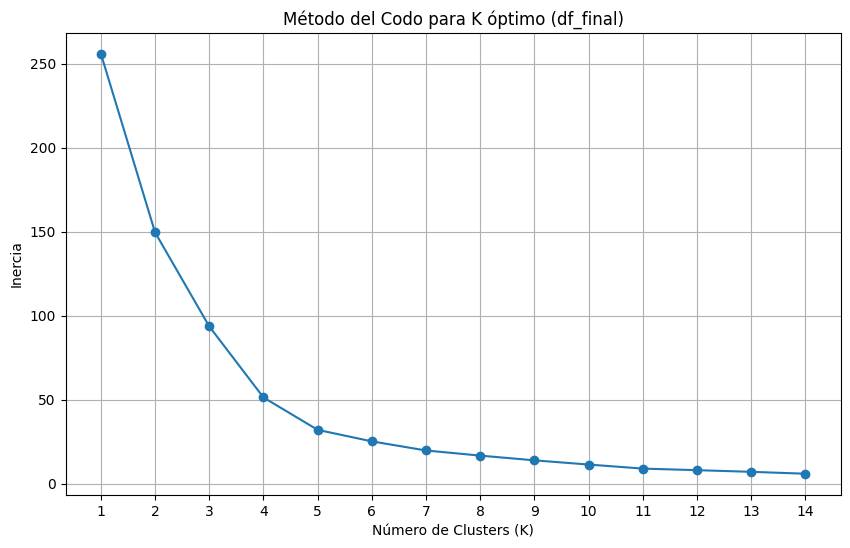

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_final = []
for k in range(1, 15):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled_final)
    inertia_final.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 15), inertia_final, marker='o')
plt.title('Método del Codo para K óptimo (df_final)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.xticks(range(1, 15))
plt.grid(True)
plt.show()

In [ ]:
optimal_k_final = 4
kmeans_final = KMeans(n_clusters=optimal_k_final, random_state=42, n_init=10)
df_clustering_final['Cluster'] = kmeans_final.fit_predict(df_scaled_final)
display(df_clustering_final.head())

,EMIGRANTES_2020,EMIGRANTES_2025,EMIGRANTES_2015,EMIGRANTES_2010,Total_Victimas_2015_2019,Total_Victimas_2020_2024,Pobreza_2015_2019,Pobreza_2020_2024,Cluster
ENTIDAD_FEDERATIVA,,,,,,,,,
Aguascalientes,38907.0,39738.0,37571.0,24874.0,23672,27687,54.4,53.9,1
Baja California,120507.0,126355.0,112513.0,114625.0,88940,97932,45.5,35.9,1
Baja California Sur,35149.0,38025.0,32368.0,28724.0,13705,14766,40.2,40.9,1
Campeche,49237.0,48884.0,49614.0,28675.0,2454,17118,90.0,95.6,1
Chiapas,192830.0,201770.0,183352.0,126496.0,20540,19040,153.5,142.9,0


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca_final = pca.fit_transform(df_scaled_final)
df_pca_final = pd.DataFrame(data = df_pca_final, columns = ['PC1', 'PC2'], index=df_clustering_final.index)
df_pca_final['Cluster'] = df_clustering_final['Cluster']

display(df_pca_final.head())

,PC1,PC2,Cluster
ENTIDAD_FEDERATIVA,,,
Aguascalientes,-1.763048,0.473929,1
Baja California,-0.459547,1.937387,1
Baja California Sur,-1.979213,0.769391,1
Campeche,-1.331023,-1.099047,1
Chiapas,1.016605,-2.868416,0


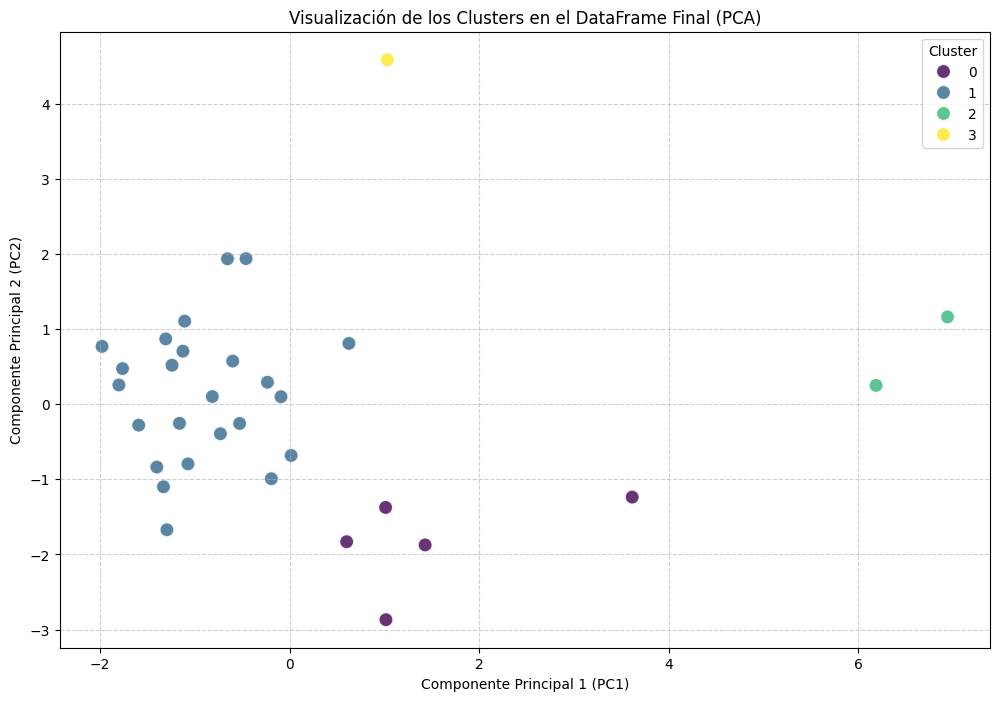

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster', data=df_pca_final,
    palette='viridis', s=100, alpha=0.8, legend='full'
)

plt.title('Visualización de los Clusters en el DataFrame Final (PCA)')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
cluster_characteristics = df_clustering_final.groupby('Cluster').mean()
display(cluster_characteristics)

,EMIGRANTES_2020,EMIGRANTES_2025,EMIGRANTES_2015,EMIGRANTES_2010,Total_Victimas_2015_2019,Total_Victimas_2020_2024,Pobreza_2015_2019,Pobreza_2020_2024
Cluster,,,,,,,,
0,240619.60,240214.200000,241673.600000,167287.000000,40795.8,46603.800000,132.700000,123.3000
1,89666.75,91852.666667,87111.916667,71475.833333,34105.0,37811.166667,70.691667,65.9875
2,650914.00,636884.500000,663370.000000,549782.500000,88530.0,108392.500000,74.100000,74.2000
3,79856.00,79930.000000,80748.000000,59232.000000,366160.0,424099.000000,100.300000,91.1000


In [ ]:
display(df_pca_final.head(32))

,PC1,PC2,Cluster
ENTIDAD_FEDERATIVA,,,
Aguascalientes,-1.763048,0.473929,1
Baja California,-0.459547,1.937387,1
Baja California Sur,-1.979213,0.769391,1
Campeche,-1.331023,-1.099047,1
Chiapas,1.016605,-2.868416,0
Chihuahua,-1.107199,1.105410,1
Ciudad de México,6.942937,1.161358,2
Coahuila,-1.307000,0.868767,1
Colima,-1.801362,0.255606,1


---

---

**Actualización del 2 de marzo de 2026**

---

---


In [ ]:
data_final = df_clustering_final.copy()
data_final

,EMIGRANTES_2020,EMIGRANTES_2025,EMIGRANTES_2015,EMIGRANTES_2010,Total_Victimas_2015_2019,Total_Victimas_2020_2024,Pobreza_2015_2019,Pobreza_2020_2024,Cluster
ENTIDAD_FEDERATIVA,,,,,,,,,
Aguascalientes,38907.0,39738.0,37571.0,24874.0,23672,27687,54.4,53.9,1
Baja California,120507.0,126355.0,112513.0,114625.0,88940,97932,45.5,35.9,1
Baja California Sur,35149.0,38025.0,32368.0,28724.0,13705,14766,40.2,40.9,1
Campeche,49237.0,48884.0,49614.0,28675.0,2454,17118,90.0,95.6,1
Chiapas,192830.0,201770.0,183352.0,126496.0,20540,19040,153.5,142.9,0
Chihuahua,75407.0,77870.0,73086.0,76290.0,51784,64708,56.9,42.9,1
Ciudad de México,677682.0,646796.0,711155.0,639896.0,85594,92708,57.6,56.6,2
Coahuila,75327.0,77977.0,72463.0,68685.0,33573,31574,47.3,43.8,1
Colima,39640.0,38988.0,40979.0,24394.0,10906,17167,64.0,47.2,1


In [ ]:
data_final.columns

Index(['EMIGRANTES_2020', 'EMIGRANTES_2025', 'EMIGRANTES_2015',
       'EMIGRANTES_2010', 'Total_Victimas_2015_2019',
       'Total_Victimas_2020_2024', 'Pobreza_2015_2019', 'Pobreza_2020_2024',
       'Cluster'],
      dtype='object')

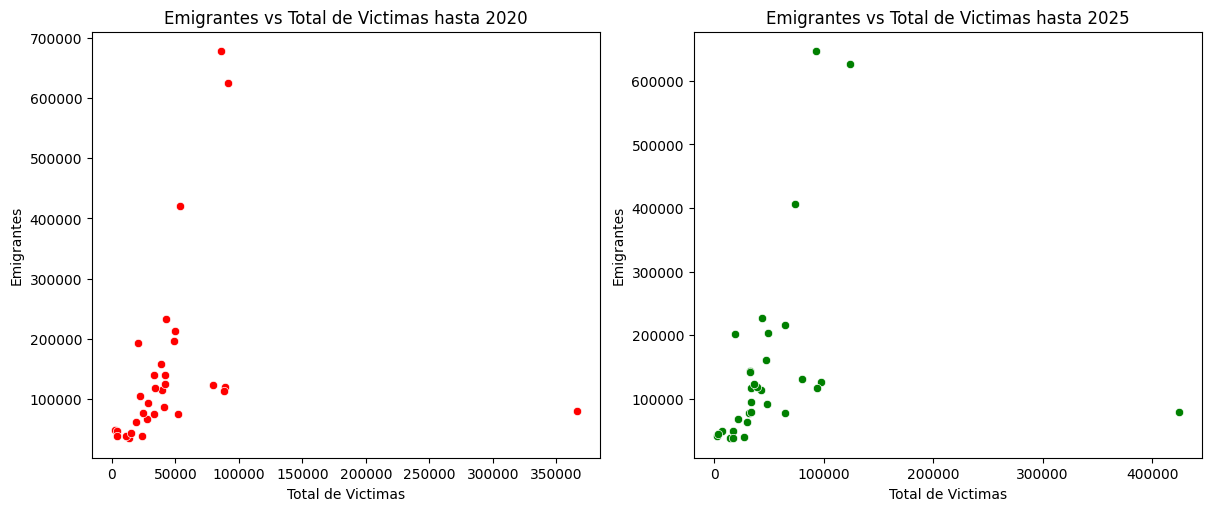

In [ ]:
fig = plt.figure( figsize=(12,5), constrained_layout=True )

ax1 = plt.subplot(121)
sns.scatterplot(data=data_final, y='EMIGRANTES_2020', x='Total_Victimas_2015_2019', ax=ax1, color='red')
ax1.set_title('Emigrantes vs Total de Victimas hasta 2020')
ax1.set_xlabel('Total de Victimas')
ax1.set_ylabel('Emigrantes')

ax2 = plt.subplot(122)
sns.scatterplot(data=data_final, y='EMIGRANTES_2025', x='Total_Victimas_2020_2024', ax=ax2, color='green')
ax2.set_title('Emigrantes vs Total de Victimas hasta 2025')
ax2.set_xlabel('Total de Victimas')
ax2.set_ylabel('Emigrantes')

plt.show()

In [ ]:
fig.savefig('emigrantes_vs_victimas.pdf', dpi=300, bbox_inches='tight')

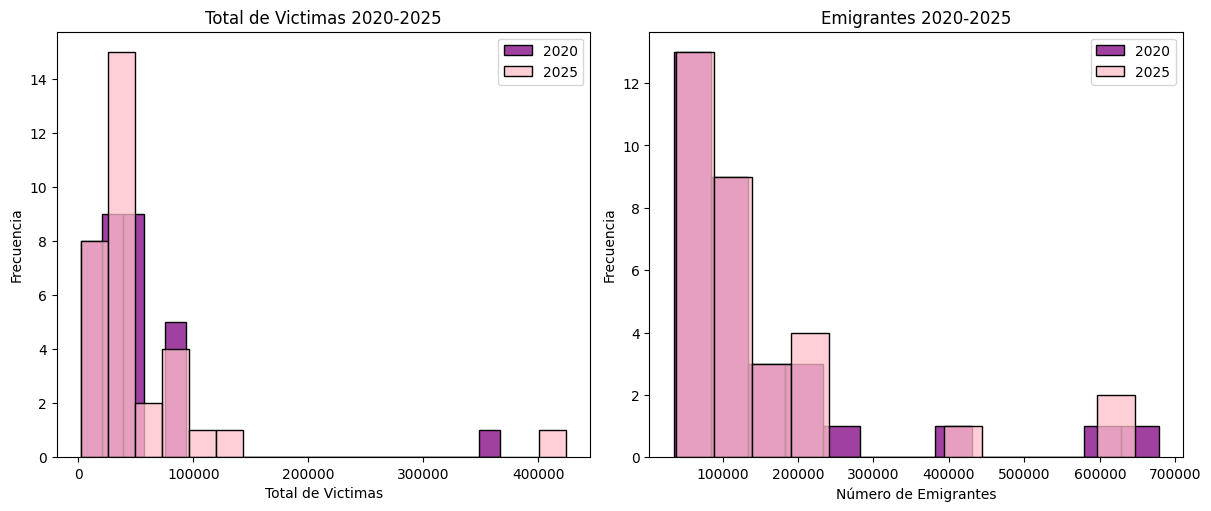

In [ ]:
fig = plt.figure( figsize=(12,5), constrained_layout=True )

ax1 = plt.subplot(121)
sns.histplot(data=data_final, x='Total_Victimas_2015_2019', ax=ax1, color='purple', label='2020')
sns.histplot(data=data_final, x='Total_Victimas_2020_2024', ax=ax1, color='pink', label='2025')
ax1.set_title('Total de Victimas 2020-2025')
ax1.set_xlabel('Total de Victimas')
ax1.set_ylabel('Frecuencia')
ax1.legend()

ax2 = plt.subplot(122)
sns.histplot(data=data_final, x='EMIGRANTES_2020', ax=ax2, color='purple', label='2020')
sns.histplot(data=data_final, x='EMIGRANTES_2025', ax=ax2, color='pink', label='2025')
ax2.set_title('Emigrantes 2020-2025')
ax2.set_xlabel('Número de Emigrantes')
ax2.set_ylabel('Frecuencia')
ax2.legend()

plt.show()

In [ ]:
fig.savefig('hist_emigrantes_vs_victimas.pdf', dpi=300, bbox_inches='tight')

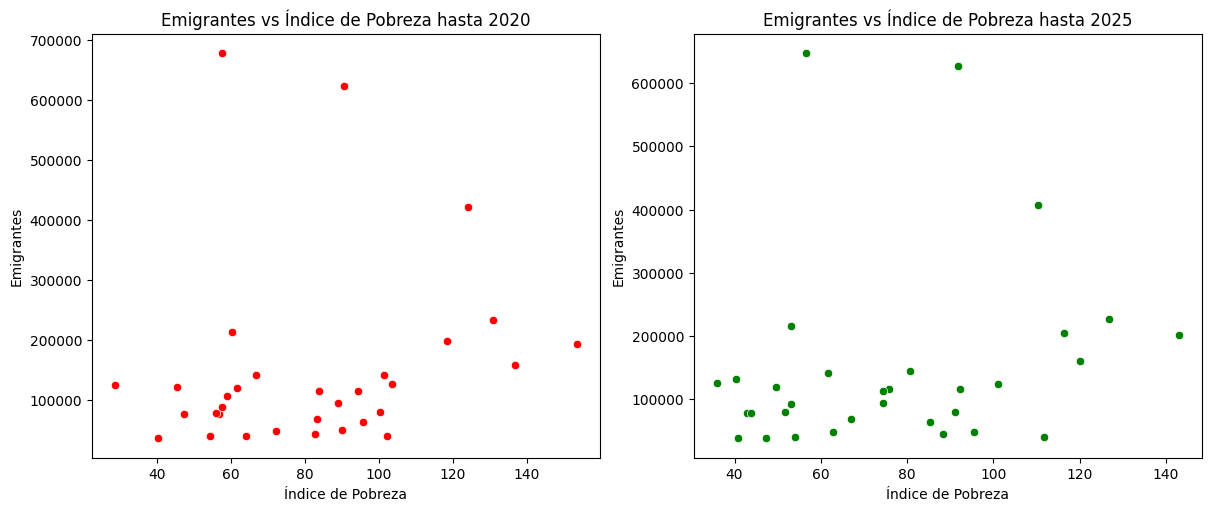

In [ ]:
fig = plt.figure( figsize=(12,5), constrained_layout=True )

ax1 = plt.subplot(121)
sns.scatterplot(data=data_final, y='EMIGRANTES_2020', x='Pobreza_2015_2019', ax=ax1, color='red')
ax1.set_title('Emigrantes vs Índice de Pobreza hasta 2020')
ax1.set_xlabel('Índice de Pobreza')
ax1.set_ylabel('Emigrantes')

ax2 = plt.subplot(122)
sns.scatterplot(data=data_final, y='EMIGRANTES_2025', x='Pobreza_2020_2024', ax=ax2, color='green')
ax2.set_title('Emigrantes vs Índice de Pobreza hasta 2025')
ax2.set_xlabel('Índice de Pobreza')
ax2.set_ylabel('Emigrantes')

plt.show()

In [ ]:
data_final[['EMIGRANTES_2025','Total_Victimas_2020_2024']].corr()

,EMIGRANTES_2025,Total_Victimas_2020_2024
EMIGRANTES_2025,1.000000,0.202254
Total_Victimas_2020_2024,0.202254,1.000000


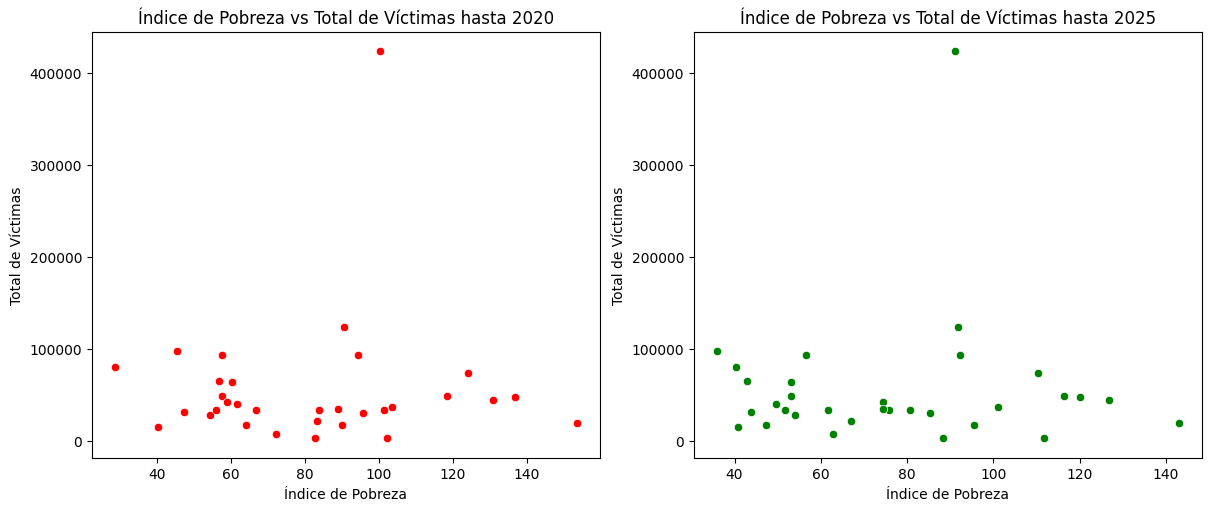

In [ ]:
fig = plt.figure( figsize=(12,5), constrained_layout=True )

ax1 = plt.subplot(121)
sns.scatterplot(data=data_final, y='Total_Victimas_2020_2024', x='Pobreza_2015_2019', ax=ax1, color='red')
ax1.set_title('Índice de Pobreza vs Total de Víctimas hasta 2020')
ax1.set_xlabel('Índice de Pobreza')
ax1.set_ylabel('Total de Víctimas')

ax2 = plt.subplot(122)
sns.scatterplot(data=data_final, y='Total_Victimas_2020_2024', x='Pobreza_2020_2024', ax=ax2, color='green')
ax2.set_title('Índice de Pobreza vs Total de Víctimas hasta 2025')
ax2.set_xlabel('Índice de Pobreza')
ax2.set_ylabel('Total de Víctimas')

plt.show()

In [ ]:
fig.savefig('pobreza_vs_victimas.pdf', dpi=300, bbox_inches='tight')

In [ ]:
import geopandas as gpd

# 2. Cargar el mapa de México (Geometrías)
# Puedes descargar uno o usar datasets incluidos en algunas librerías
url = "https://raw.githubusercontent.com/strotgen/mexico-leaflet/master/states.geojson"
mexico = gpd.read_file(url)

mexico.tail()

,id,state_code,state_name,geometry
27,None,5,Coahuila de Zaragoza,"POLYGON ((-100.87953 29.28154, -100.7949 29.24..."
28,None,28,Tamaulipas,"POLYGON ((-99.49657 27.27136, -99.44205 27.250..."
29,None,31,Yucatán,"MULTIPOLYGON (((-87.86198 21.57164, -87.73836 ..."
30,None,4,Campeche,"POLYGON ((-90.38193 20.7496, -90.38193 20.7470..."
31,None,23,Quintana Roo,"MULTIPOLYGON (((-87.36211 18.38496, -87.38239 ..."


In [ ]:
df_final.head()

,ENTIDAD_FEDERATIVA,EMIGRANTES_2020,EMIGRANTES_2025,EMIGRANTES_2015,EMIGRANTES_2010,Total_Victimas_2015_2019,Total_Victimas_2020_2024,Pobreza_2015_2019,Pobreza_2020_2024
0,Aguascalientes,38907.0,39738.0,37571.0,24874.0,23672,27687,54.4,53.9
1,Baja California,120507.0,126355.0,112513.0,114625.0,88940,97932,45.5,35.9
2,Baja California Sur,35149.0,38025.0,32368.0,28724.0,13705,14766,40.2,40.9
3,Campeche,49237.0,48884.0,49614.0,28675.0,2454,17118,90.0,95.6
4,Chiapas,192830.0,201770.0,183352.0,126496.0,20540,19040,153.5,142.9


In [ ]:
name_corrections = {
    'Veracruz': 'Veracruz de Ignacio de la Llave',
    'Estado de México': 'México',
    'Michoacán': 'Michoacán de Ocampo',
    'Coahuila': 'Coahuila de Zaragoza',
    'Ciudad de México': 'Distrito Federal'
}
df_final['ENTIDAD_FEDERATIVA'] = df_final['ENTIDAD_FEDERATIVA'].replace(name_corrections)

In [ ]:
mapa_datos = mexico.merge(df_final, left_on='state_name', right_on='ENTIDAD_FEDERATIVA')

mapa_datos.tail()


,id,state_code,state_name,geometry,ENTIDAD_FEDERATIVA,EMIGRANTES_2020,EMIGRANTES_2025,EMIGRANTES_2015,EMIGRANTES_2010,Total_Victimas_2015_2019,Total_Victimas_2020_2024,Pobreza_2015_2019,Pobreza_2020_2024
27,None,5,Coahuila de Zaragoza,"POLYGON ((-100.87953 29.28154, -100.7949 29.24...",Coahuila de Zaragoza,75327.0,77977.0,72463.0,68685.0,33573,31574,47.3,43.8
28,None,28,Tamaulipas,"POLYGON ((-99.49657 27.27136, -99.44205 27.250...",Tamaulipas,140853.0,142221.0,140864.0,130229.0,41887,33030,66.7,61.7
29,None,31,Yucatán,"MULTIPOLYGON (((-87.86198 21.57164, -87.73836 ...",Yucatán,43371.0,44330.0,41443.0,45741.0,15082,3344,82.7,88.3
30,None,4,Campeche,"POLYGON ((-90.38193 20.7496, -90.38193 20.7470...",Campeche,49237.0,48884.0,49614.0,28675.0,2454,17118,90.0,95.6
31,None,23,Quintana Roo,"MULTIPOLYGON (((-87.36211 18.38496, -87.38239 ...",Quintana Roo,105957.0,113713.0,93036.0,68017.0,21899,42389,59.0,74.5


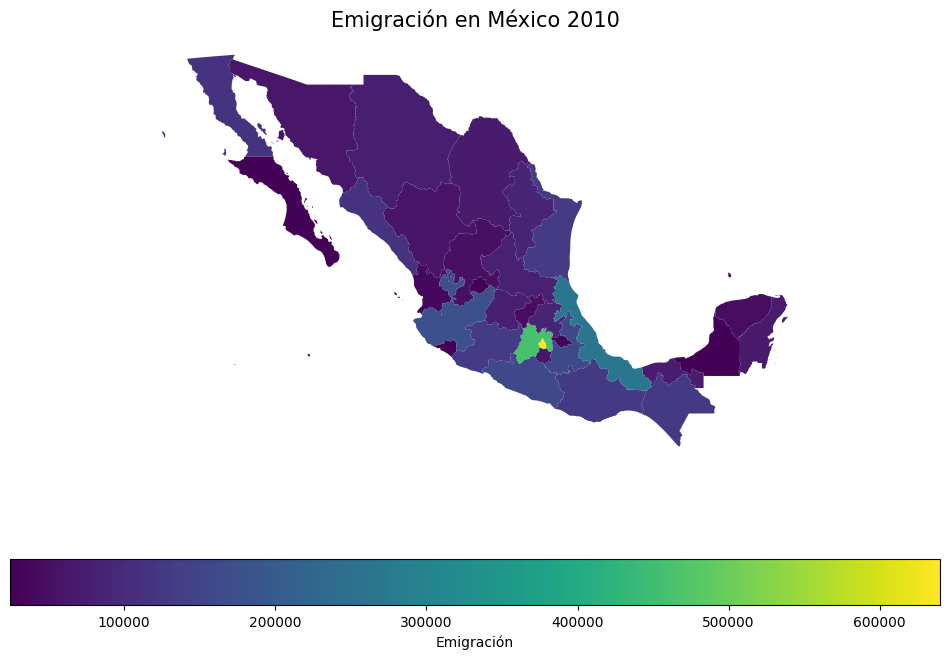

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

mapa_datos.plot(column='EMIGRANTES_2010',
                ax=ax,
                legend=True,
                cmap='viridis',
                legend_kwds={'label': "Emigración",
                             'orientation': "horizontal"})

ax.set_title('Emigración en México 2010', fontsize=15)
ax.set_axis_off()

plt.show()

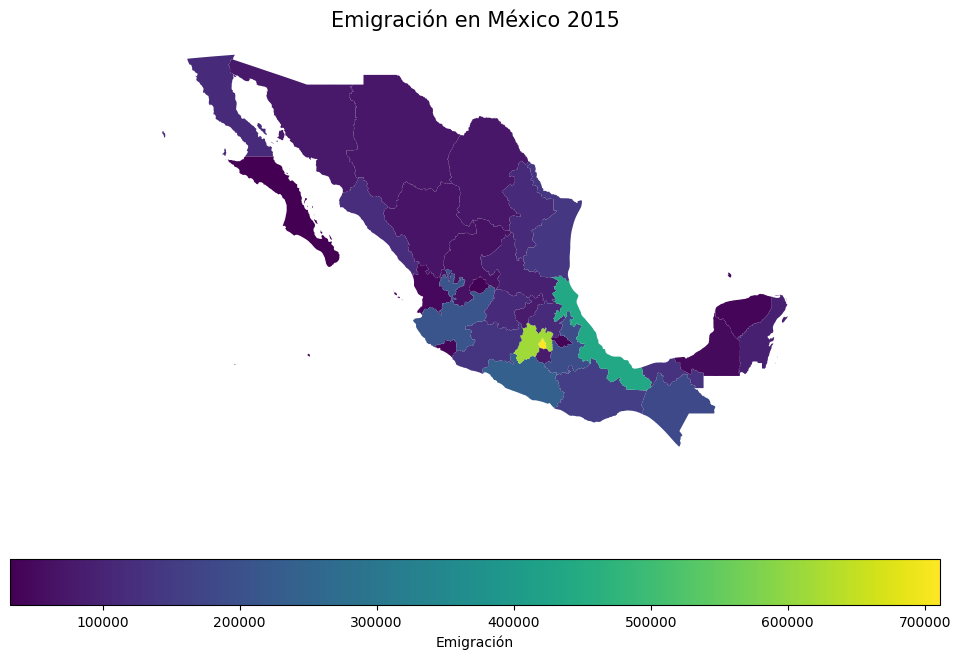

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

mapa_datos.plot(column='EMIGRANTES_2015',
                ax=ax,
                legend=True,
                cmap='viridis',
                legend_kwds={'label': "Emigración",
                             'orientation': "horizontal"})

ax.set_title('Emigración en México 2015', fontsize=15)
ax.set_axis_off()

plt.show()

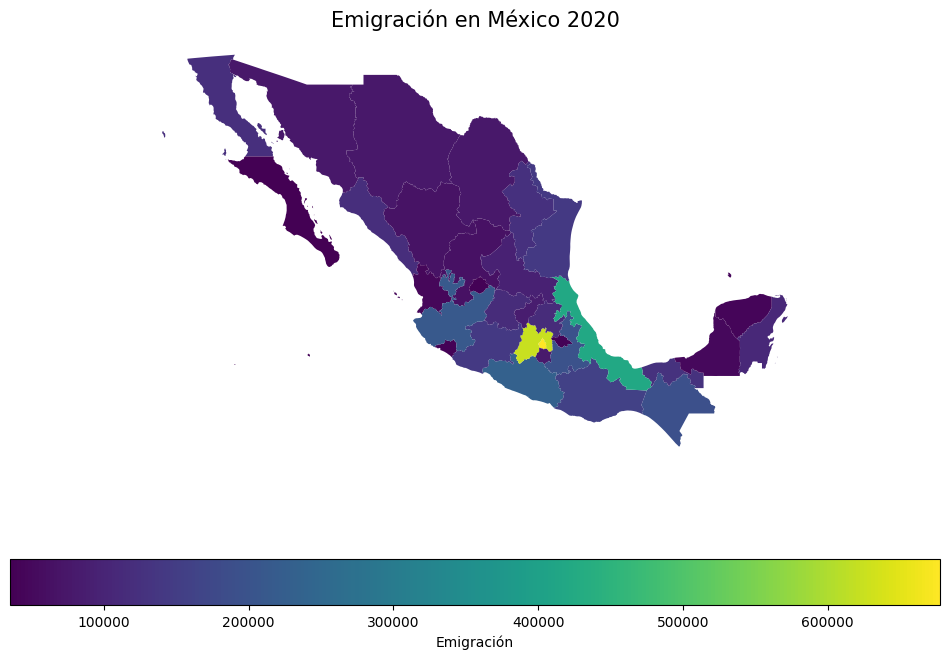

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

mapa_datos.plot(column='EMIGRANTES_2020',
                ax=ax,
                legend=True,
                cmap='viridis',
                legend_kwds={'label': "Emigración",
                             'orientation': "horizontal"})

ax.set_title('Emigración en México 2020', fontsize=15)
ax.set_axis_off()

plt.show()

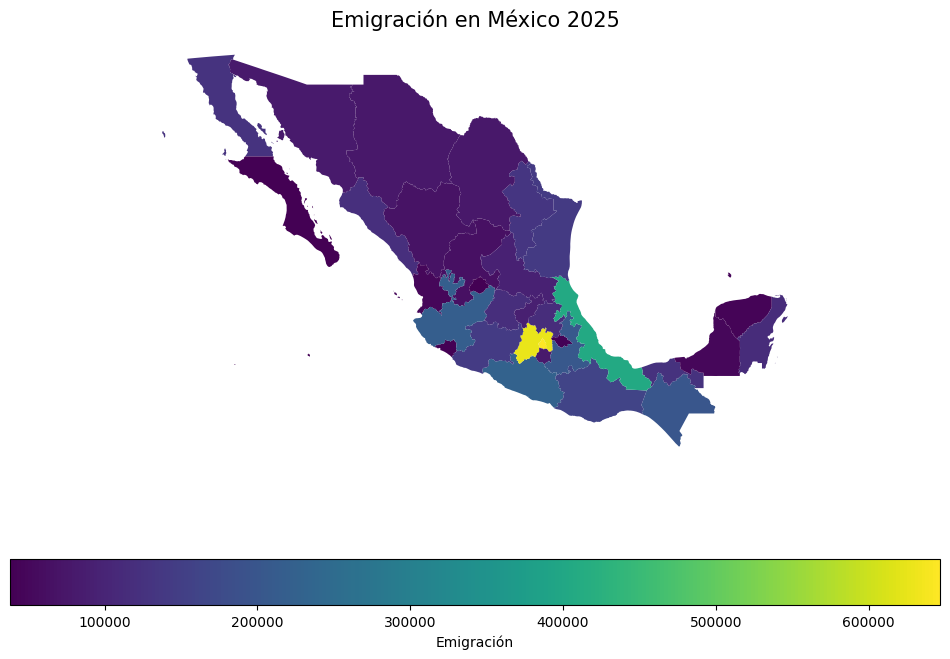

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

mapa_datos.plot(column='EMIGRANTES_2025',
                ax=ax,
                legend=True,
                cmap='viridis',
                legend_kwds={'label': "Emigración",
                             'orientation': "horizontal"})

ax.set_title('Emigración en México 2025', fontsize=15)
ax.set_axis_off()

plt.show()